# 🏆 OnePilot — Forecasting | Notebook 5 : Ensemble
**Objectif** : Comparer les 7 combinaisons sur données **hebdomadaires** (base équitable)  
**Sélection** : MAE minimum sur 20 semaines de test  
**Output** : meilleur modèle + prévisions finales

In [1]:
import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
from prophet import Prophet
from pmdarima import auto_arima
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import logging, warnings
warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
plt.rcParams.update({
    'figure.facecolor': '#060a0e', 'axes.facecolor': '#0d1520',
    'axes.edgecolor': '#182336',   'text.color': '#d8e8f2',
    'axes.labelcolor': '#7ea4be',  'xtick.color': '#7ea4be',
    'ytick.color': '#7ea4be',      'grid.color': '#182336',
    'grid.linestyle': '--',        'grid.alpha': 0.5
})
print('✅ Imports OK')

✅ Imports OK


In [2]:
# ── Chargement données hebdomadaires ─────────────────────────────
train_w = pd.read_csv('/tmp/northwind_weekly_train.csv', index_col='date', parse_dates=True)
test_w  = pd.read_csv('/tmp/northwind_weekly_test.csv',  index_col='date', parse_dates=True)
full_w  = pd.read_csv('/tmp/northwind_weekly.csv',       index_col='date', parse_dates=True)

train_series = train_w['revenu'].astype(float)
test_series  = test_w['revenu'].astype(float)
full_series  = full_w['revenu'].astype(float)

n_test    = len(test_series)
n_horizon = 12  # 12 semaines supplémentaires (~3 mois)
n_total   = n_test + n_horizon

print(f'✅ Données hebdomadaires')
print(f'   Train : {len(train_series)} semaines')
print(f'   Test  : {n_test} semaines')
print(f'   Horizon extra : {n_horizon} semaines')

✅ Données hebdomadaires
   Train : 79 semaines
   Test  : 20 semaines
   Horizon extra : 12 semaines


In [3]:
# ══════════════════════════════════════════════════════════════════
# MODÈLE 1 — SARIMA hebdomadaire
# ══════════════════════════════════════════════════════════════════
print('1️⃣  SARIMA hebdomadaire...')

sarima_model = auto_arima(
    train_series,
    seasonal=True, m=52,
    d=None, D=None,
    stepwise=True,
    max_p=2, max_q=2, max_P=1, max_Q=1,
    information_criterion='aic',
    suppress_warnings=True, error_action='ignore', trace=False
)

sarima_fc, sarima_ci = sarima_model.predict(n_periods=n_total, return_conf_int=True)
sarima_fc = np.clip(sarima_fc, 0, None)

mae_sarima = mean_absolute_error(test_series, sarima_fc[:n_test])
print(f'   Modèle : SARIMA{sarima_model.order}')
print(f'   MAE    : {mae_sarima:,.0f} €  ✅')

1️⃣  SARIMA hebdomadaire...
   Modèle : SARIMA(0, 1, 1)
   MAE    : 10,463 €  ✅


In [4]:
# ══════════════════════════════════════════════════════════════════
# MODÈLE 2 — Prophet hebdomadaire
# ══════════════════════════════════════════════════════════════════
print('2️⃣  Prophet hebdomadaire...')

df_train_p = pd.DataFrame({'ds': train_series.index, 'y': train_series.values})

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.3,
    interval_width=0.95
)
prophet_model.fit(df_train_p)

future_p = prophet_model.make_future_dataframe(periods=n_total, freq='W')
fc_p = prophet_model.predict(future_p)
fc_p_future = fc_p[fc_p['ds'] > train_series.index[-1]].head(n_total)
prophet_fc = np.clip(fc_p_future['yhat'].values, 0, None)
prophet_lo = np.clip(fc_p_future['yhat_lower'].values, 0, None)
prophet_hi = fc_p_future['yhat_upper'].values

mae_prophet = mean_absolute_error(test_series, prophet_fc[:n_test])
print(f'   Changepoints : {len(prophet_model.changepoints)}')
print(f'   MAE          : {mae_prophet:,.0f} €  ✅')

23:13:19 - cmdstanpy - INFO - Chain [1] start processing
23:13:19 - cmdstanpy - INFO - Chain [1] done processing


2️⃣  Prophet hebdomadaire...
   Changepoints : 25
   MAE          : 15,954 €  ✅


In [5]:
# ══════════════════════════════════════════════════════════════════
# MODÈLE 3 — LSTM (réutiliser le modèle entraîné Notebook 4)
# ══════════════════════════════════════════════════════════════════
print('3️⃣  LSTM (rechargement du modèle Notebook 4)...')

WINDOW = 8

class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            dropout=dropout if num_layers > 1 else 0, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze()

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_series.values.reshape(-1,1)).flatten()

lstm_model = LSTMForecaster().to(device)
lstm_model.load_state_dict(torch.load('/tmp/lstm_model.pt', map_location=device))
lstm_model.eval()

# Prévision récursive
window = list(train_scaled[-WINDOW:])
preds_sc = []
with torch.no_grad():
    for _ in range(n_total):
        x_in = torch.FloatTensor(window[-WINDOW:]).unsqueeze(0).unsqueeze(-1).to(device)
        pred = lstm_model(x_in).item()
        preds_sc.append(pred)
        window.append(pred)

lstm_fc = scaler.inverse_transform(np.clip(preds_sc, 0, 1).reshape(-1,1) ).flatten()
lstm_fc = np.clip(lstm_fc, 0, None)

mae_lstm = mean_absolute_error(test_series, lstm_fc[:n_test])
print(f'   MAE : {mae_lstm:,.0f} €  ✅')

3️⃣  LSTM (rechargement du modèle Notebook 4)...
   MAE : 11,890 €  ✅


In [6]:
# ══════════════════════════════════════════════════════════════════
# 7 COMBINAISONS — calcul MAE
# ══════════════════════════════════════════════════════════════════
s = sarima_fc[:n_test]
p = prophet_fc[:n_test]
l = lstm_fc[:n_test]
y = test_series.values

combos = {
    'SARIMA':           (s,                         mae_sarima),
    'Prophet':          (p,                         mae_prophet),
    'LSTM':             (l,                         mae_lstm),
    'SARIMA+Prophet':   ((s+p)/2,                   mean_absolute_error(y, (s+p)/2)),
    'SARIMA+LSTM':      ((s+l)/2,                   mean_absolute_error(y, (s+l)/2)),
    'Prophet+LSTM':     ((p+l)/2,                   mean_absolute_error(y, (p+l)/2)),
    'SARIMA+Prophet+LSTM': ((s+p+l)/3,              mean_absolute_error(y, (s+p+l)/3)),
}

df_results = pd.DataFrame([
    {'Combinaison': k, 'MAE': v[1], 'MAE_fmt': f"{v[1]:,.0f} €"}
    for k, v in combos.items()
]).sort_values('MAE').reset_index(drop=True)

best_name = df_results.iloc[0]['Combinaison']
best_mae  = df_results.iloc[0]['MAE']

print('='*50)
print('  CLASSEMENT 7 COMBINAISONS (hebdomadaire)')
print('='*50)
for i, row in df_results.iterrows():
    badge = ' ← SÉLECTIONNÉ ✅' if row['Combinaison'] == best_name else ''
    print(f"  {i+1}. {row['Combinaison']:<25} MAE: {row['MAE_fmt']}{badge}")
print(f'\n  Meilleur modèle : {best_name}')
print(f'  MAE             : {best_mae:,.0f} €')

  CLASSEMENT 7 COMBINAISONS (hebdomadaire)
  1. SARIMA                    MAE: 10,463 € ← SÉLECTIONNÉ ✅
  2. SARIMA+LSTM               MAE: 11,138 €
  3. LSTM                      MAE: 11,890 €
  4. SARIMA+Prophet+LSTM       MAE: 12,743 €
  5. SARIMA+Prophet            MAE: 13,170 €
  6. Prophet+LSTM              MAE: 13,922 €
  7. Prophet                   MAE: 15,954 €

  Meilleur modèle : SARIMA
  MAE             : 10,463 €


In [7]:
# ── Prévisions finales avec le meilleur modèle ────────────────────
# Index de dates futures
last_train = train_w.index[-1]
future_idx = pd.date_range(start=last_train + pd.Timedelta(weeks=1),
                            periods=n_total, freq='W')

best_fc_test = combos[best_name][0]
# Prévisions horizon complet
if best_name == 'SARIMA':
    best_fc_full = sarima_fc
    best_lo = np.clip(sarima_ci[:,0], 0, None)
    best_hi = sarima_ci[:,1]
elif best_name == 'Prophet':
    best_fc_full = prophet_fc
    best_lo = prophet_lo
    best_hi = prophet_hi
elif best_name == 'LSTM':
    best_fc_full = lstm_fc
    best_lo = lstm_fc * 0.85
    best_hi = lstm_fc * 1.15
else:
    # Combinaison — moyenne des modèles concernés
    models_in = best_name.split('+')
    fc_list = []
    lo_list, hi_list = [], []
    if 'SARIMA'  in models_in: fc_list.append(sarima_fc);  lo_list.append(np.clip(sarima_ci[:,0],0,None)); hi_list.append(sarima_ci[:,1])
    if 'Prophet' in models_in: fc_list.append(prophet_fc); lo_list.append(prophet_lo); hi_list.append(prophet_hi)
    if 'LSTM'    in models_in: fc_list.append(lstm_fc);    lo_list.append(lstm_fc*0.85); hi_list.append(lstm_fc*1.15)
    best_fc_full = np.mean(fc_list, axis=0)
    best_lo = np.mean(lo_list, axis=0)
    best_hi = np.mean(hi_list, axis=0)

df_final = pd.DataFrame({
    'forecast': best_fc_full,
    'lower_95': best_lo,
    'upper_95': best_hi
}, index=future_idx)

print(f'✅ Prévisions finales — {best_name}')
print(df_final.head(8).round(0).to_string())

✅ Prévisions finales — SARIMA
            forecast  lower_95  upper_95
1998-01-04       NaN    3856.0   22480.0
1998-01-11       NaN    3788.0   22548.0
1998-01-18       NaN    3721.0   22615.0
1998-01-25       NaN    3654.0   22682.0
1998-02-01       NaN    3588.0   22748.0
1998-02-08       NaN    3522.0   22814.0
1998-02-15       NaN    3457.0   22879.0
1998-02-22       NaN    3392.0   22944.0


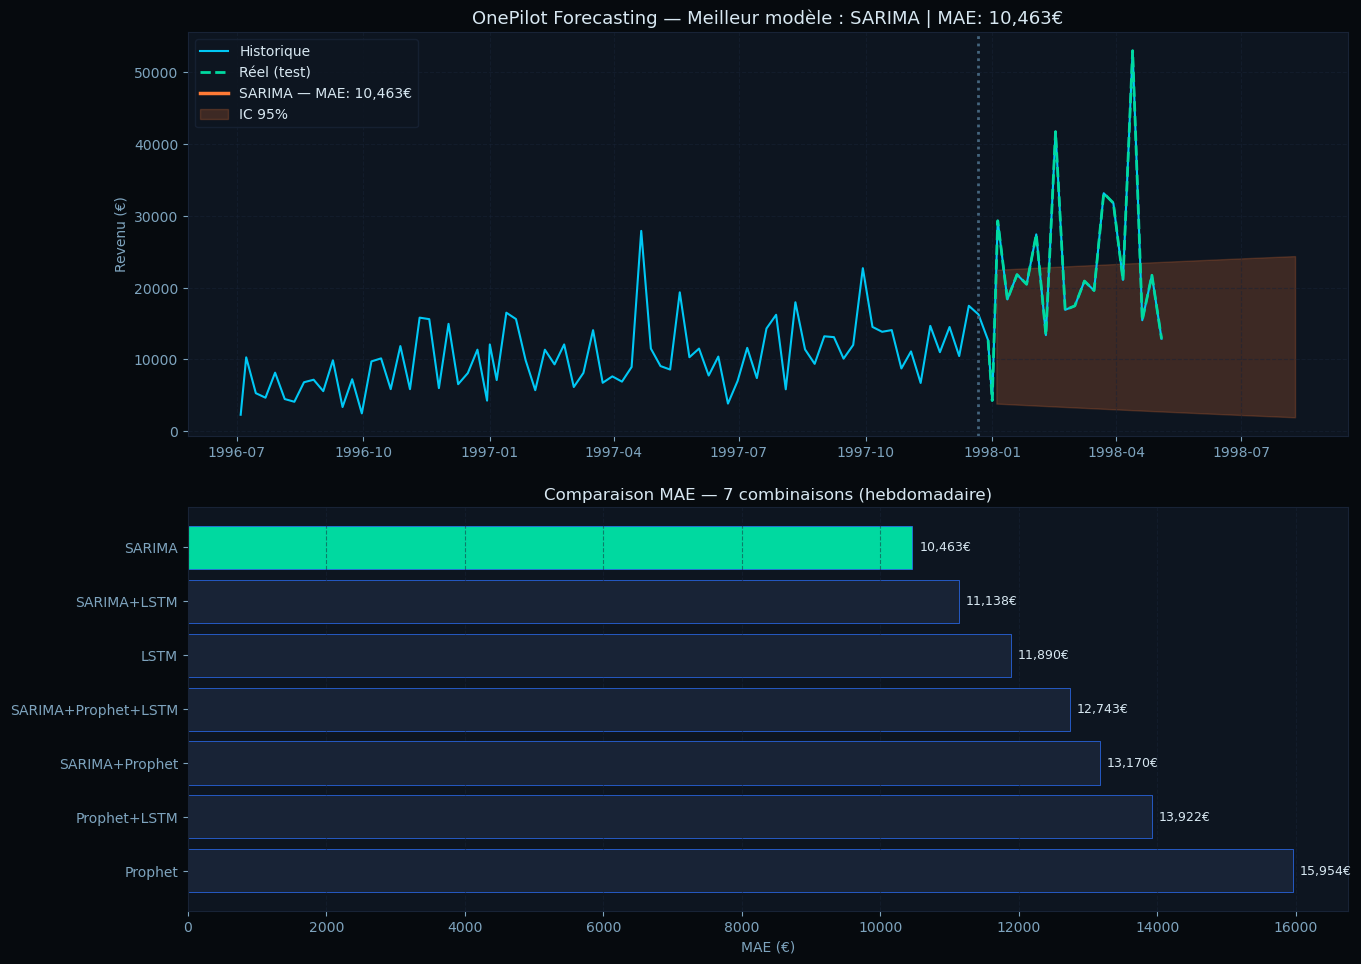

✅ Graphique sauvegardé → /tmp/ensemble_final.png


In [8]:
# ── Visualisation finale ──────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Graphique 1 — Prévision finale du meilleur modèle
ax1 = axes[0]
ax1.plot(full_w.index, full_series, color='#00c8f5', lw=1.5, label='Historique')
ax1.plot(test_w.index, test_series, color='#00d9a0', lw=2,
         linestyle='--', label='Réel (test)', zorder=4)
ax1.plot(df_final.index, df_final['forecast'],
         color='#ff7a35', lw=2.5, label=f'{best_name} — MAE: {best_mae:,.0f}€', zorder=5)
ax1.fill_between(df_final.index, df_final['lower_95'], df_final['upper_95'],
                 alpha=0.2, color='#ff7a35', label='IC 95%')
ax1.axvline(x=train_w.index[-1], color='#45657e', linestyle=':', lw=2)
ax1.set_title(f'OnePilot Forecasting — Meilleur modèle : {best_name} | MAE: {best_mae:,.0f}€',
              color='#d8e8f2', fontsize=13)
ax1.set_ylabel('Revenu (€)', color='#7ea4be')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.legend(facecolor='#0d1520', edgecolor='#182336', labelcolor='#d8e8f2')
ax1.grid(True)

# Graphique 2 — Tableau comparatif MAE
ax2 = axes[1]
colors = ['#00d9a0' if r['Combinaison'] == best_name else '#182336'
          for _, r in df_results.iterrows()]
bars = ax2.barh(df_results['Combinaison'], df_results['MAE'], color=colors, edgecolor='#2d72ff', lw=0.5)
ax2.set_title('Comparaison MAE — 7 combinaisons (hebdomadaire)', color='#d8e8f2', fontsize=12)
ax2.set_xlabel('MAE (€)', color='#7ea4be')
for bar, (_, row) in zip(bars, df_results.iterrows()):
    ax2.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             f"{row['MAE']:,.0f}€", va='center', color='#d8e8f2', fontsize=9)
ax2.grid(True, axis='x')
ax2.invert_yaxis()

plt.tight_layout(pad=2)
plt.savefig('/tmp/ensemble_final.png', dpi=120, bbox_inches='tight', facecolor='#060a0e')
plt.show()
print('✅ Graphique sauvegardé → /tmp/ensemble_final.png')

In [9]:
# ── Sauvegarde finale ─────────────────────────────────────────────
df_final.to_csv('/tmp/ensemble_best_forecast.csv')
df_results.to_csv('/tmp/ensemble_results.csv', index=False)

print('✅ Résultats sauvegardés :')
print('   /tmp/ensemble_best_forecast.csv → prévisions finales')
print('   /tmp/ensemble_results.csv       → classement 7 combinaisons')
print()
print('='*50)
print('  RÉSUMÉ FINAL FORECASTING')
print('='*50)
print(f'  Meilleur modèle : {best_name}')
print(f'  MAE             : {best_mae:,.0f} €')
print(f'  Granularité     : hebdomadaire')
print(f'  Horizon         : {n_horizon} semaines supplémentaires')
print()
print('→ Prochain : Notebook 6 — Intégration dans forecast_agent.py')

✅ Résultats sauvegardés :
   /tmp/ensemble_best_forecast.csv → prévisions finales
   /tmp/ensemble_results.csv       → classement 7 combinaisons

  RÉSUMÉ FINAL FORECASTING
  Meilleur modèle : SARIMA
  MAE             : 10,463 €
  Granularité     : hebdomadaire
  Horizon         : 12 semaines supplémentaires

→ Prochain : Notebook 6 — Intégration dans forecast_agent.py
